In [30]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

In [31]:
zarr_path = "/Users/clairenastaskin/data/Post_acquisition_parameter_sweep/sub-Forest001/ses-20250708/task-movements_run-004/Reconstructed_volumes_include_bias_frames_in_reconstuction_but_dont_substract/bmode/bmode.zarr"

arr = zarr.open(zarr_path, mode='r')
print(f"Array shape: {arr.shape}, chunks: {arr.chunks}")

# Find which chunk indices along dim 0 are initialized (i.e. exist on disk)
import os
chunk_files = sorted([f for f in os.listdir(zarr_path) if f[0].isdigit()])
volume_indices = sorted([int(f.split('.')[0]) for f in chunk_files])
print(f"Found {len(volume_indices)} initialized volumes: {volume_indices}")

Array shape: (600, 200, 183, 88, 142), chunks: (1, 200, 183, 88, 142)
Found 8 initialized volumes: [0, 1, 10, 11, 12, 13, 14, 15]


In [32]:
# Extract first 3 frames of each 4D volume and compute global mean signal
# arr shape is (N, 200, 183, 88, 142) — first dim indexes the 4D volumes,
# second dim (200) contains the frames we want to slice from
n_bias_frames = 3
global_signals_bias_frames = {}  # {volume_index: [mean_frame0, mean_frame1, mean_frame2]}

for idx in volume_indices:
    means = []
    for i in range(n_bias_frames):
        frame = arr[idx, i, :, :, :]  # shape: (183, 88, 142)
        means.append(float(np.nanmean(frame)))
    global_signals_bias_frames[idx] = means
    print(f"Volume {idx}: frame means = {means}")

Volume 0: frame means = [162.04229736328125, 162.51321411132812, 163.2092742919922]
Volume 1: frame means = [162.35906982421875, 161.7489471435547, 162.39617919921875]
Volume 10: frame means = [163.46128845214844, 162.2581329345703, 162.091796875]
Volume 11: frame means = [162.2528076171875, 161.71115112304688, 162.84336853027344]
Volume 12: frame means = [162.45416259765625, 162.45925903320312, 162.5786895751953]
Volume 13: frame means = [162.02822875976562, 162.38218688964844, 163.32815551757812]
Volume 14: frame means = [162.5558319091797, 162.44137573242188, 162.09698486328125]
Volume 15: frame means = [162.76568603515625, 162.6028289794922, 163.5785369873047]


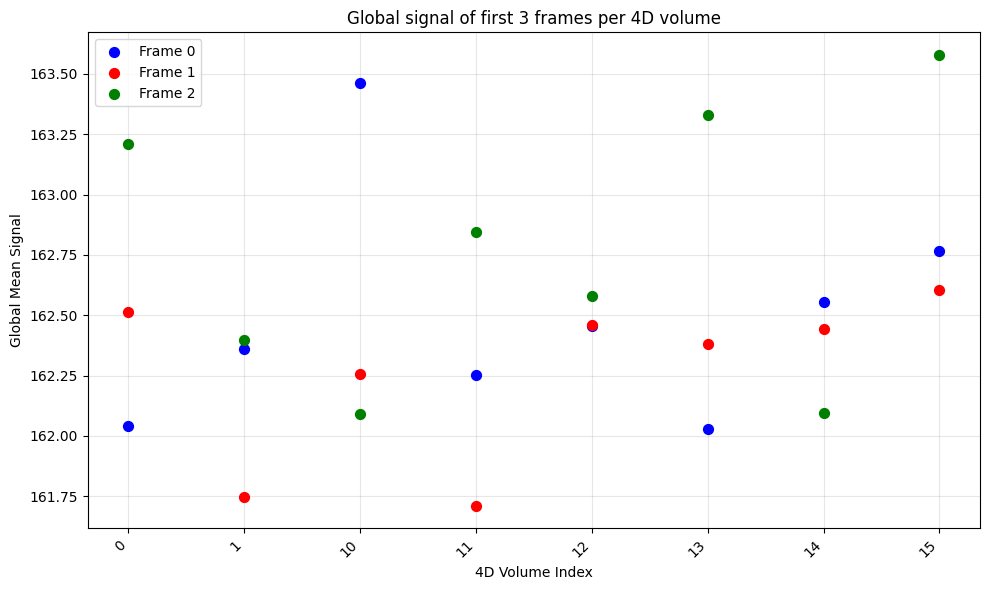

In [33]:
# Plot
colors = ['blue', 'red', 'green']
labels = ['Frame 0', 'Frame 1', 'Frame 2']

fig, ax = plt.subplots(figsize=(max(10, len(volume_indices) * 0.6), 6))

x_positions = np.arange(len(volume_indices))
x_labels = [str(idx) for idx in volume_indices]

for frame_idx in range(n_bias_frames):
    y_values = [global_signals_bias_frames[idx][frame_idx] for idx in volume_indices]
    ax.scatter(x_positions, y_values, color=colors[frame_idx], label=labels[frame_idx],
               marker='o', s=50, zorder=3)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_xlabel('4D Volume Index')
ax.set_ylabel('Global Mean Signal')
ax.set_title('Global signal of first 3 frames per 4D volume')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_11873/1077376808.py:23: RuntimeWarning: Mean of empty slice
  depth_profile = np.nanmean(frame, axis=(0, 1))  # shape: (142,)


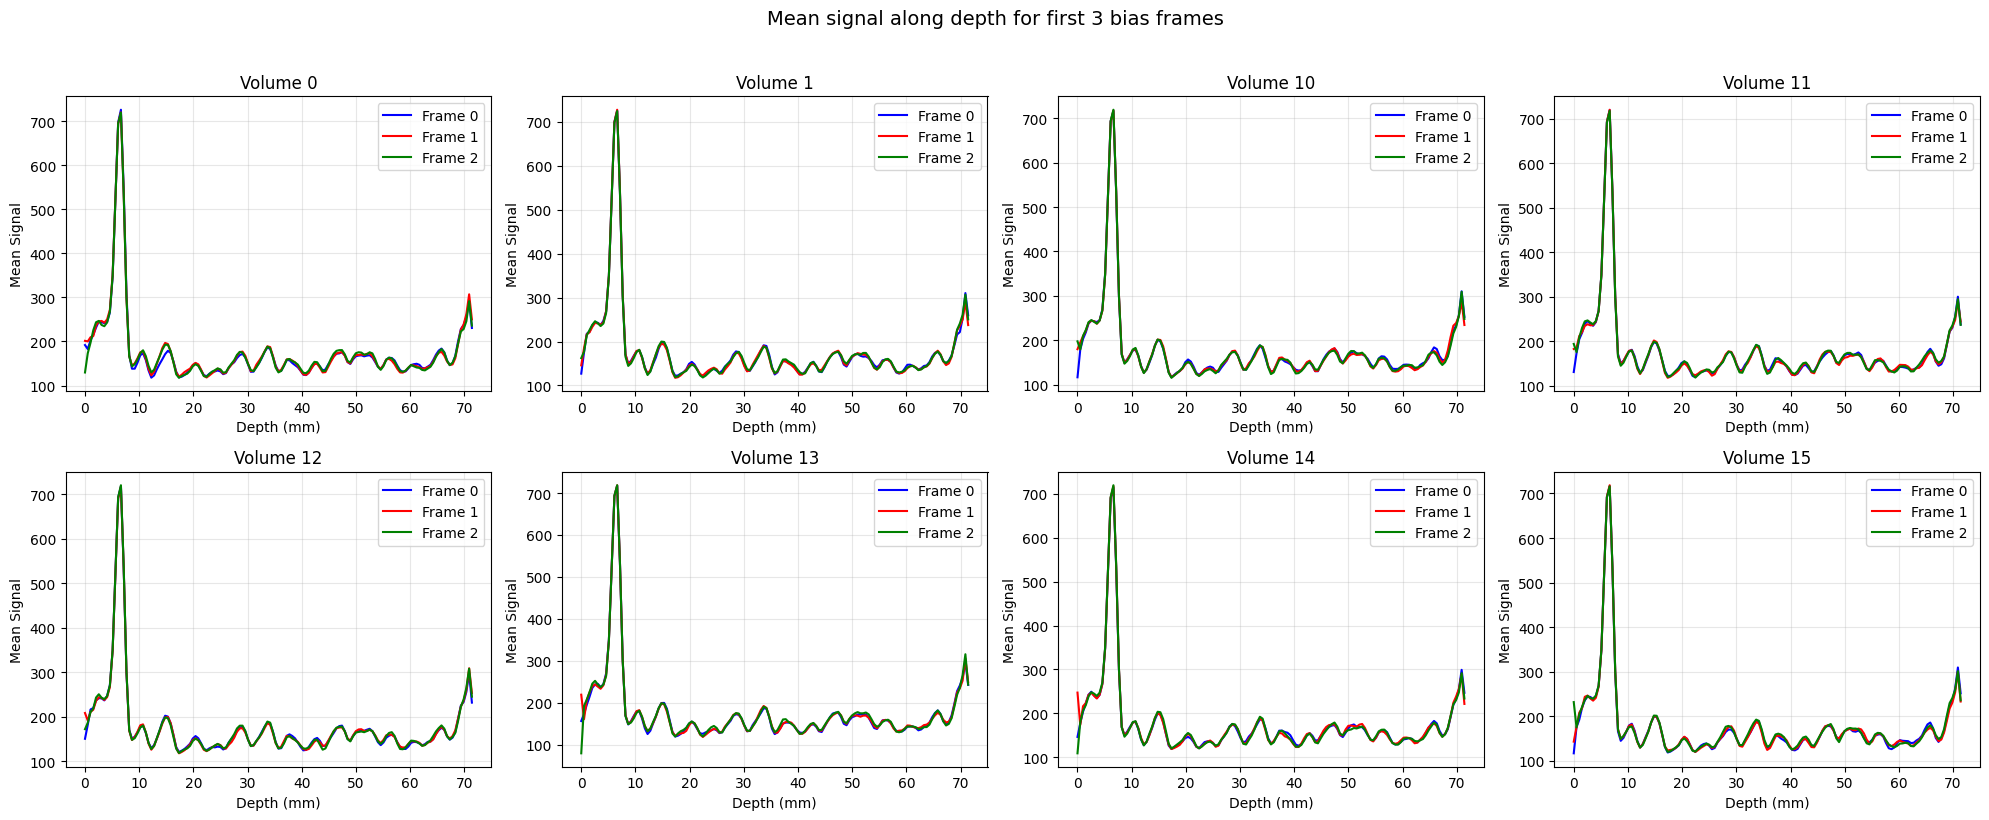

In [34]:
# For each 4D volume, plot mean signal along depth (last dim, size 142)
# for each of the first 3 bias frames.
# For frame arr[idx, i, :, :, :] of shape (183, 88, 142),
# average over the first two spatial dims -> depth profile of shape (142,)

voxel_size_mm = 0.51
n_depth = arr.shape[-1]  # 142
depth_mm = np.arange(n_depth) * voxel_size_mm

colors = ['blue', 'red', 'green']
labels = ['Frame 0', 'Frame 1', 'Frame 2']

n_cols = min(4, len(volume_indices))
n_rows = int(np.ceil(len(volume_indices) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for vol_num, idx in enumerate(volume_indices):
    row, col = divmod(vol_num, n_cols)
    ax = axes[row, col]
    for i in range(n_bias_frames):
        frame = arr[idx, i, :, :, :]  # shape: (183, 88, 142)
        depth_profile = np.nanmean(frame, axis=(0, 1))  # shape: (142,)
        ax.plot(depth_mm, depth_profile, color=colors[i], label=labels[i])
    ax.set_title(f'Volume {idx}')
    ax.set_xlabel('Depth (mm)')
    ax.set_ylabel('Mean Signal')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for vol_num in range(len(volume_indices), n_rows * n_cols):
    row, col = divmod(vol_num, n_cols)
    axes[row, col].set_visible(False)

fig.suptitle('Mean signal along depth for first 3 bias frames', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_11873/702994804.py:12: RuntimeWarning: Mean of empty slice
  depth_profile = np.nanmean(frame, axis=(0, 1))  # shape: (142,)


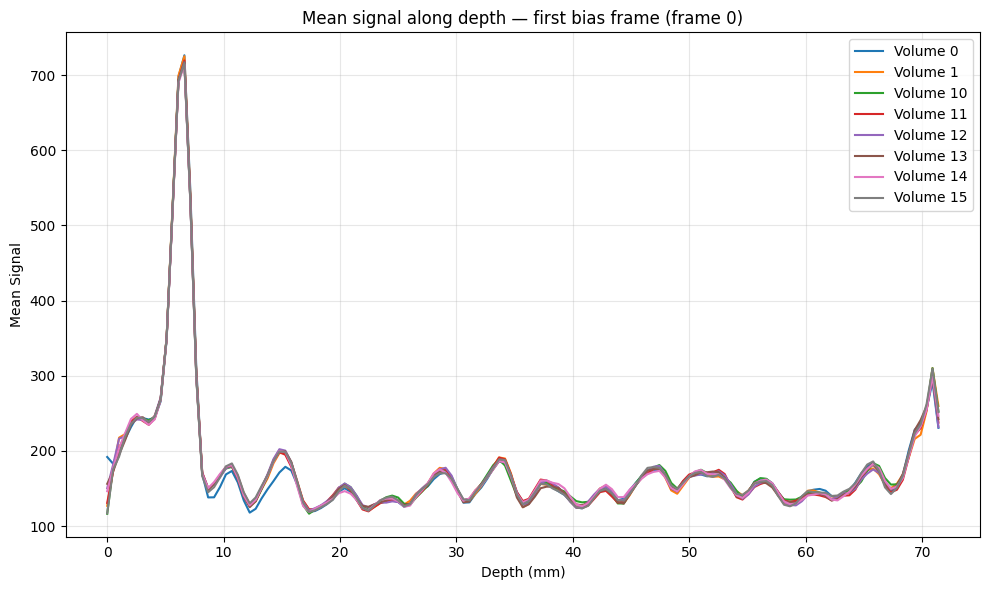

In [35]:
# Plot mean signal along depth of the first bias frame (frame 0)
# for all 4D volumes overlaid on the same graph.

voxel_size_mm = 0.51
n_depth = arr.shape[-1]  # 142
depth_mm = np.arange(n_depth) * voxel_size_mm

fig, ax = plt.subplots(figsize=(10, 6))

for idx in volume_indices:
    frame = arr[idx, 0, :, :, :]  # first bias frame only, shape: (183, 88, 142)
    depth_profile = np.nanmean(frame, axis=(0, 1))  # shape: (142,)
    ax.plot(depth_mm, depth_profile, label=f"Volume {idx}")

ax.set_xlabel("Depth (mm)")
ax.set_ylabel("Mean Signal")
ax.set_title("Mean signal along depth — first bias frame (frame 0)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Extract all frames after the third frame of each 4D volume and compute global mean signal
# arr shape is (N, 200, 183, 88, 142) — first dim indexes the 4D volumes,
# second dim (200) contains the frames we want to slice from

global_signals_non_bias = {}  # {volume_index: [mean_frame0, mean_frame1, mean_frame2]}

for idx in volume_indices:
    means = []
    for i in range(n_bias_frames, arr.shape[1]):  # Start from frame 3 onwards

        frame = arr[idx, i, :, :, :]  # shape: (183, 88, 142)
        means.append(float(np.nanmean(frame)))
    global_signals_non_bias[idx] = means
    print(f"Volume {idx}: frame means = {means}")


Volume 0: frame means = [1695.268798828125, 1694.85693359375, 1697.7117919921875, 1697.5120849609375, 1699.1767578125, 1699.4998779296875, 1699.7486572265625, 1701.3157958984375, 1702.3846435546875, 1702.533203125, 1702.728515625, 1702.9466552734375, 1705.11083984375, 1704.72607421875, 1705.96044921875, 1706.5931396484375, 1706.918212890625, 1707.30810546875, 1709.65234375, 1709.7515869140625, 1710.1800537109375, 1710.378662109375, 1711.703125, 1711.74169921875, 1712.645751953125, 1713.584716796875, 1713.4287109375, 1714.1527099609375, 1713.7080078125, 1715.34375, 1716.217041015625, 1715.081787109375, 1715.0714111328125, 1714.970458984375, 1715.6953125, 1712.4267578125, 1711.429931640625, 1713.06591796875, 1711.9615478515625, 1713.7550048828125, 1716.0362548828125, 1714.7340087890625, 1715.31591796875, 1715.4351806640625, 1713.633544921875, 1713.4539794921875, 1713.9239501953125, 1713.8033447265625, 1715.0811767578125, 1714.289306640625, 1714.8883056640625, 1715.6572265625, 1714.065917

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_11873/1910416166.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


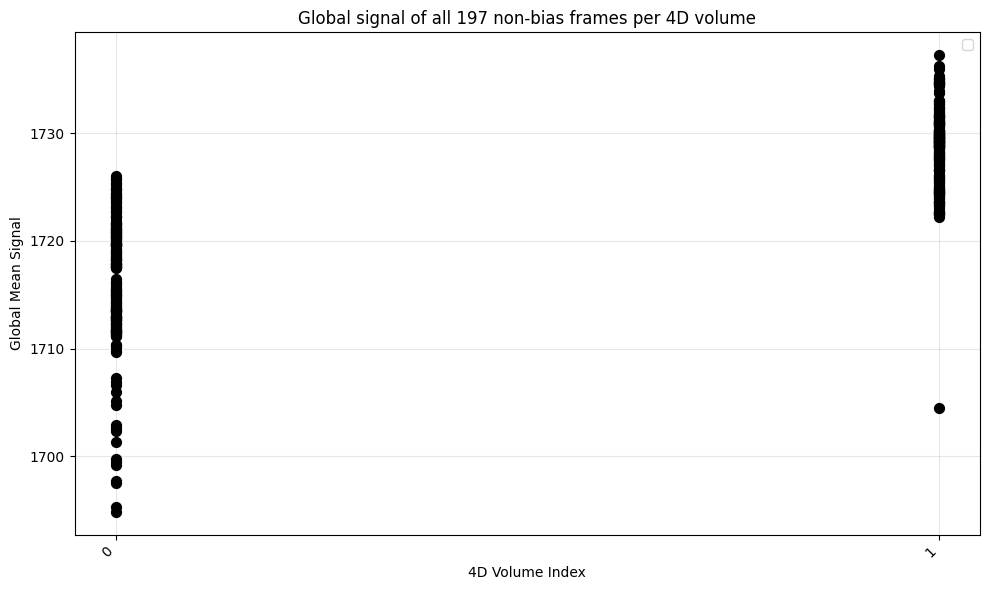

In [ ]:
# Plot

fig, ax = plt.subplots(figsize=(max(10, len(volume_indices) * 0.6), 6))

x_positions = np.arange(len(volume_indices))
x_labels = [str(idx) for idx in volume_indices]

for frame_idx in range(arr.shape[1] - n_bias_frames):  # Loop through all frames after the first 3
    y_values = [global_signals_non_bias[idx][frame_idx] for idx in volume_indices]
    ax.scatter(x_positions, y_values, color='black',
               marker='o', s=50, zorder=3)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_xlabel('4D Volume Index')
ax.set_ylabel('Global Mean Signal')
ax.set_title('Global signal of all 197 non-bias frames per 4D volume')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()